# Wetterich equation ϕ4 flow in d = 3

In [156]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import h5py

### Litim Regulator

/tmp/ipykernel_7009/1264617393.py:5: RuntimeWarning: divide by zero encountered in scalar divide
  return y*(1/y-1)
/tmp/ipykernel_7009/1264617393.py:5: RuntimeWarning: invalid value encountered in scalar multiply
  return y*(1/y-1)


Text(0, 0.5, 'R_k/K²')

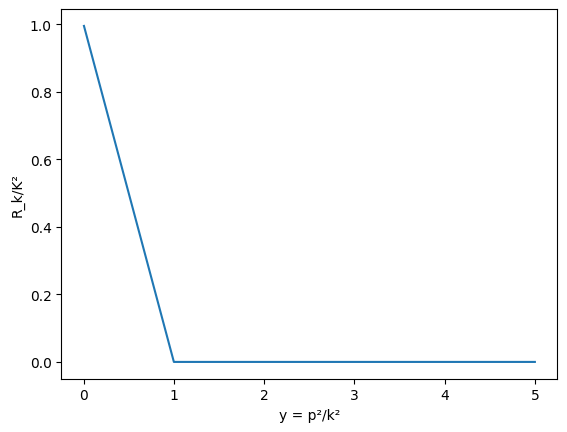

In [157]:
def litim(y):
    if 1 < y:
        return 0
    else:
        return y*(1/y-1)
    
y = np.linspace(0,5,1000)
R_vals = np.zeros(1000)

for i in range(len(y)):
    R_vals[i] = litim(y[i])

plt.plot(y, R_vals)
plt.xlabel("y = p²/k²")
plt.ylabel("R_k/K²")

## Classical ϕ4 potential and derivatives

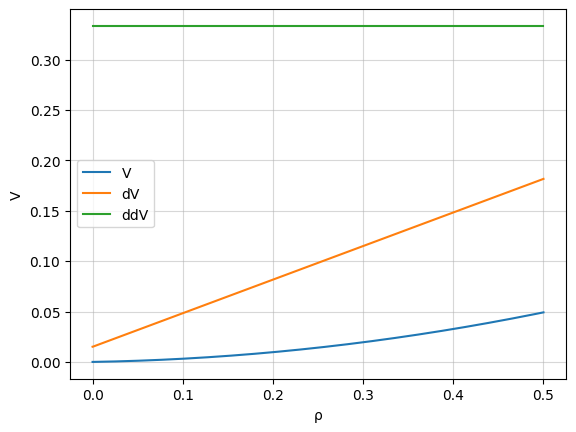

In [158]:
data = np.loadtxt("../results/V_classical.txt", skiprows=1, delimiter=",")
data_1 = np.loadtxt("../results/V_classical_prime.txt", skiprows=1, delimiter=",")
data_2 = np.loadtxt("../results/V_classical_doubleprime.txt", skiprows=1, delimiter=",")

ρ = data[:,0]
V = data[:,1]

ρ2 = data_1[:,0]
dV = data_1[:,1]

ρ3 = data_2[:,0]
ddV = data_2[:,1]

plt.plot(ρ,V,label="V")
plt.xlabel("ρ")
plt.ylabel("V")
plt.plot(ρ2,dV, label="dV")
plt.plot(ρ3,ddV, label="ddV")
plt.legend()
plt.grid(alpha=0.5)
plt.show()

### initial RHS of Flow equation

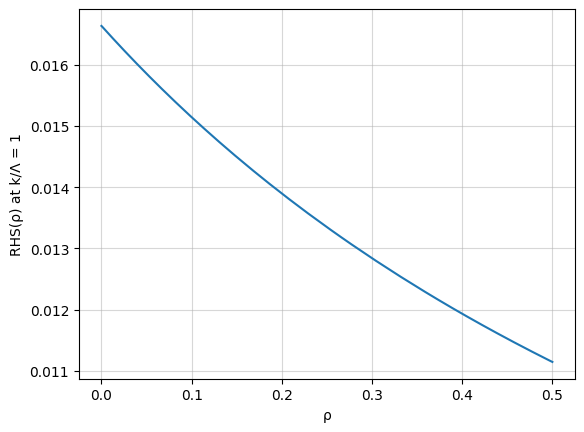

In [159]:
RHS = np.loadtxt("../results/RHS.txt", skiprows=1, delimiter=",")

ρ = RHS[:,0]
RHS = RHS[:,1]

plt.plot(ρ,RHS)
plt.xlabel("ρ")
# plt.xscale("log")
# plt.yscale("log")
plt.ylabel("RHS(ρ) at k/Λ = 1")
plt.grid(alpha=0.5)

## Flow equation solution

Read fron CSV file

In [160]:
CSV_PATH = Path("../results/flow_adaptive.csv")

In [161]:
def read_block(path, block_name):
    rows = []
    header = None
    inside = False
    with open(path) as f:
        for line in f:
            if line.startswith(f"# block: {block_name}"):
                inside = True
                continue
            if inside and line.startswith("# block:"):
                break          # next block started
            if inside and line.startswith("#"):
                continue       # other comment
            if inside:
                if header is None:
                    header = line.strip().split(",")
                else:
                    rows.append([float(x) for x in line.strip().split(",")])

    data = np.array(rows)
    rho = data[:, 0]
    k_vals = np.array([float(h.split("=")[1]) for h in header[1:]])

    # Older CSV files round very small k values to 0.000000 in the header.
    # Keep only positive finite entries so log(k) stays defined.
    valid = np.isfinite(k_vals) & (k_vals > 0)
    if not np.all(valid):
        k_vals = k_vals[valid]
        data = data[:, np.r_[True, valid]]

    matrix = data[:, 1:].T    # shape: (n_snapshots, n_rho)
    return rho, k_vals, matrix


rho_grid, k_values, V_grid = read_block(CSV_PATH, "V")
_, _, RHS_grid = read_block(CSV_PATH, "RHS")
t_values = np.log(k_values)

## Flow of the effective potential

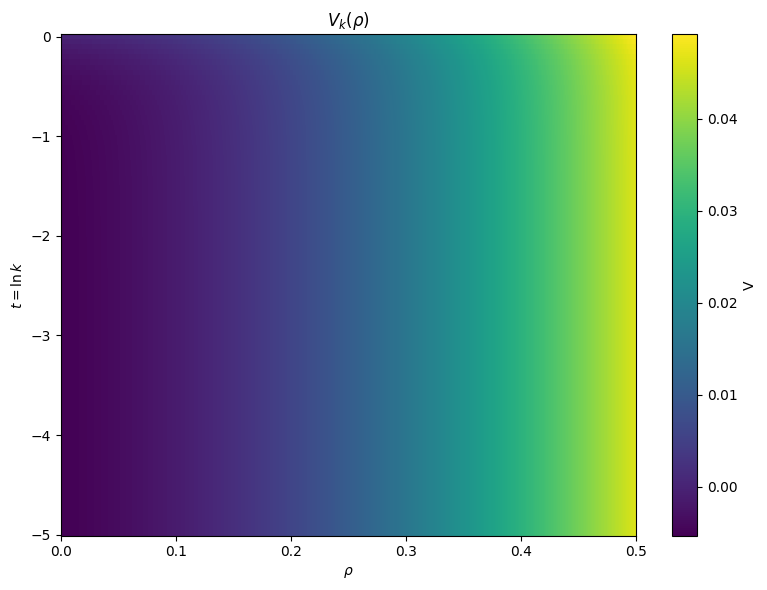

In [162]:
fig, ax = plt.subplots(figsize=(8, 6))
mesh = ax.pcolormesh(rho_grid, t_values, V_grid, shading="auto", cmap="viridis")
ax.set_xlabel(r"$\rho$")
ax.set_ylabel(r"$t = \ln k$")
ax.set_title(r"$V_k(\rho)$")
fig.colorbar(mesh, ax=ax, label="V")
plt.tight_layout()
plt.show()

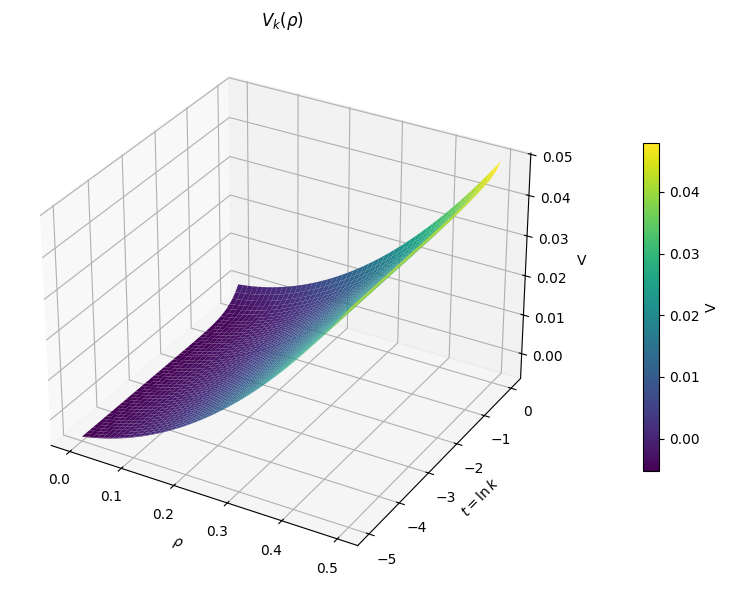

In [163]:
Rho, T = np.meshgrid(rho_grid, t_values)

fig = plt.figure(figsize=(9, 6))
ax  = fig.add_subplot(111, projection="3d")
surf = ax.plot_surface(Rho, T, V_grid, cmap="viridis", edgecolor="none")
ax.set_xlabel(r"$\rho$")
ax.set_ylabel(r"$t = \ln k$")
ax.set_zlabel("V")
ax.set_title(r"$V_k(\rho)$")
fig.colorbar(surf, ax=ax, shrink=0.6, pad=0.1, label="V")
plt.tight_layout()
plt.show()

## Flow of the effective potential relative to the initial condition

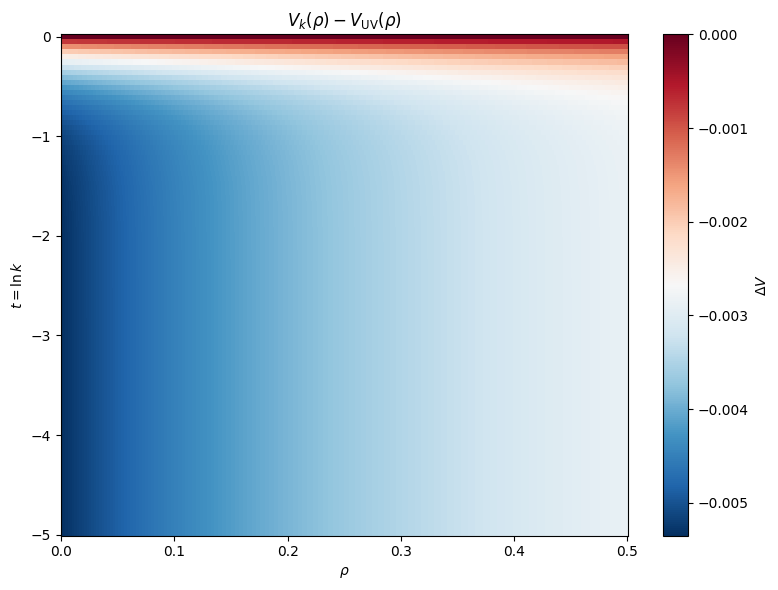

In [164]:
V_ref  = V_grid[0]          # UV snapshot  (largest k)
V_diff = V_grid - V_ref

fig, ax = plt.subplots(figsize=(8, 6))
mesh = ax.pcolormesh(rho_grid, t_values, V_diff, shading="auto", cmap="RdBu_r")
ax.set_xlabel(r"$\rho$")
ax.set_ylabel(r"$t = \ln k$")
ax.set_title(r"$V_k(\rho) - V_{\mathrm{UV}}(\rho)$")
fig.colorbar(mesh, ax=ax, label=r"$\Delta V$")
plt.tight_layout()
plt.show()

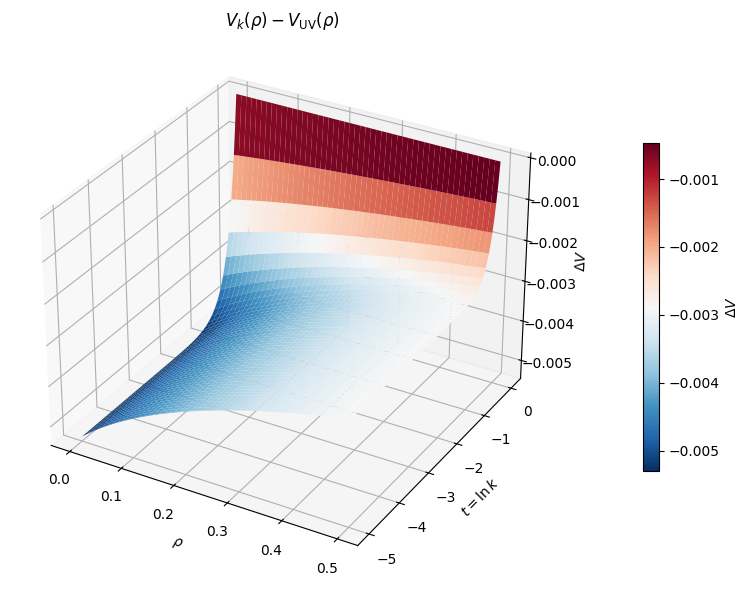

In [165]:
Rho, T = np.meshgrid(rho_grid, t_values)

fig = plt.figure(figsize=(9, 6))
ax  = fig.add_subplot(111, projection="3d")
surf = ax.plot_surface(Rho, T, V_diff, cmap="RdBu_r", edgecolor="none")
ax.set_xlabel(r"$\rho$")
ax.set_ylabel(r"$t = \ln k$")
ax.set_zlabel(r"$\Delta V$")
ax.set_title(r"$V_k(\rho) - V_{\mathrm{UV}}(\rho)$")
fig.colorbar(surf, ax=ax, shrink=0.6, pad=0.1, label=r"$\Delta V$")
plt.tight_layout()
plt.show()

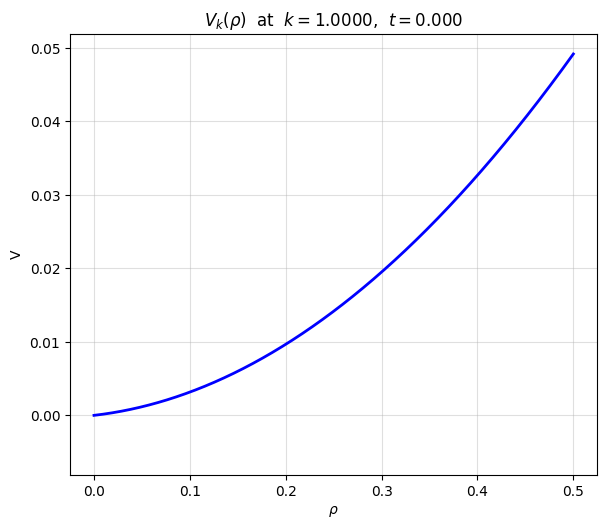

In [166]:
fig, ax = plt.subplots(figsize=(6, 5))

# Fix y-limits across all frames
y_min, y_max = V_grid.min(), V_grid.max()
margin = 0.05 * (y_max - y_min)

def animate(frame):
    ax.clear()
    ax.plot(rho_grid, V_grid[frame], "b-", linewidth=2)
    ax.set_xlabel(r"$\rho$")
    ax.set_ylabel("V")
    ax.set_title(rf"$V_k(\rho)$  at  $k = {k_values[frame]:.4f}$,  $t = {t_values[frame]:.3f}$")
    ax.set_ylim(y_min - margin, y_max + margin)
    ax.grid(alpha=0.4)

anim = FuncAnimation(fig, animate, frames=len(t_values), interval=120, repeat=True)
plt.tight_layout()
HTML(anim.to_jshtml())

## Flowing minimum of potential

/tmp/ipykernel_7009/1010266948.py:10: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  ax.set_yscale("log")


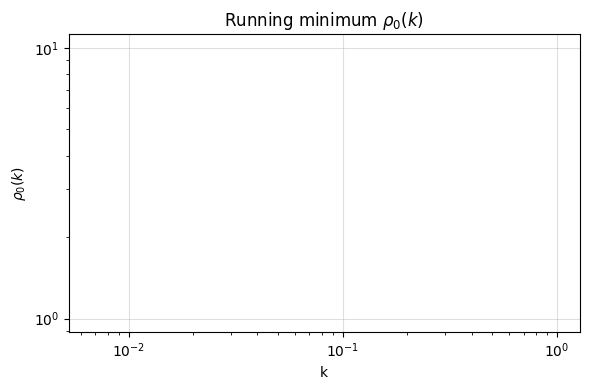

In [167]:
# Find the rho at which V is minimised for each snapshot
rho0 = rho_grid[np.argmin(V_grid, axis=1)]

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(k_values, rho0, "o-", color="tab:orange")
ax.set_xlabel("k")
ax.set_ylabel(r"$\rho_0(k)$")
ax.set_title(r"Running minimum $\rho_0(k)$")
ax.set_xscale("log")
ax.set_yscale("log")
ax.grid(alpha=0.4)
plt.tight_layout()
plt.show()

## RHS of Wetterich equation

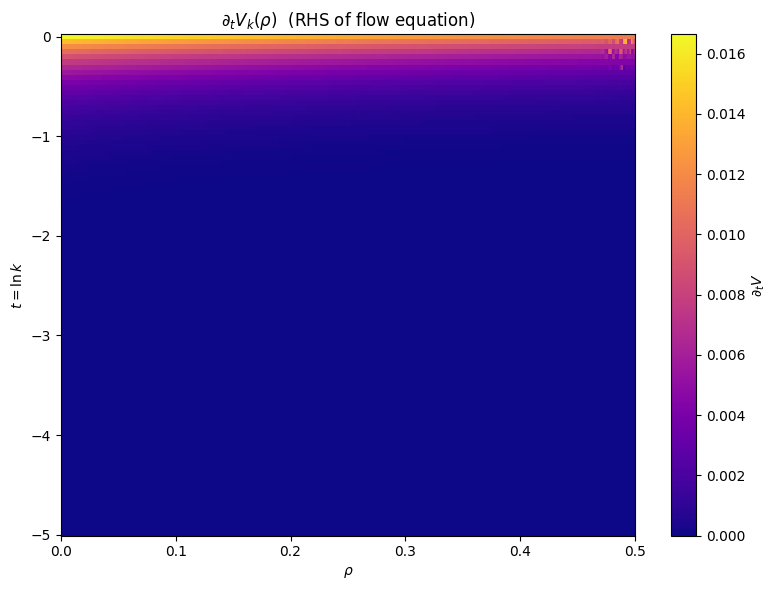

In [168]:
fig, ax = plt.subplots(figsize=(8, 6))
mesh = ax.pcolormesh(rho_grid, t_values, RHS_grid, shading="auto", cmap="plasma")
ax.set_xlabel(r"$\rho$")
ax.set_ylabel(r"$t = \ln k$")
ax.set_title(r"$\partial_t V_k(\rho)$  (RHS of flow equation)")
fig.colorbar(mesh, ax=ax, label=r"$\partial_t V$")
plt.tight_layout()

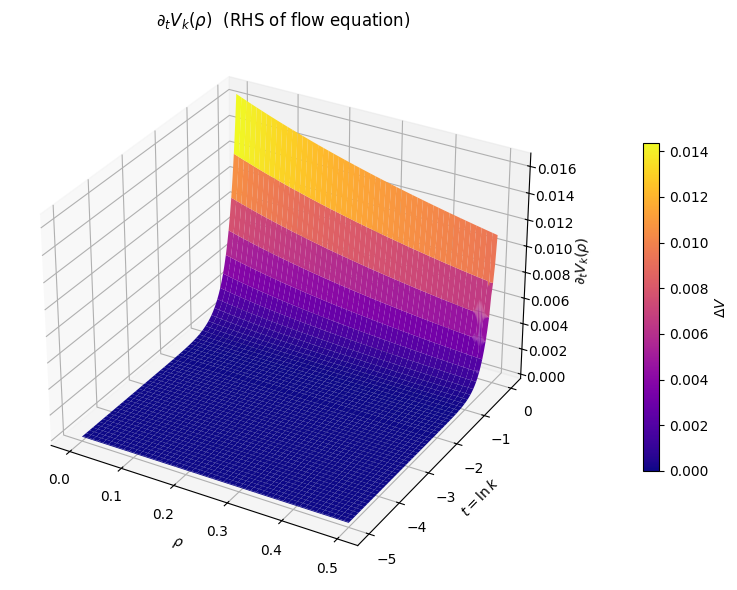

In [169]:
Rho, T = np.meshgrid(rho_grid, t_values)

fig = plt.figure(figsize=(9, 6))
ax  = fig.add_subplot(111, projection="3d")
surf = ax.plot_surface(Rho, T, RHS_grid, cmap="plasma", edgecolor="none")
ax.set_xlabel(r"$\rho$")
ax.set_ylabel(r"$t = \ln k$")
ax.set_zlabel(r"$\partial_t V_k(\rho)$")
ax.set_title(r"$\partial_t V_k(\rho)$  (RHS of flow equation)")
fig.colorbar(surf, ax=ax, shrink=0.6, pad=0.1, label=r"$\Delta V$")
plt.tight_layout()
plt.show()